<a href="https://colab.research.google.com/github/TanishDudeja/Week_2_AIML_TRAINING/blob/main/Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Prediction Project

This project analyzes heart disease data to predict the presence and severity of the condition using machine learning techniques, specifically comparing Decision Trees and Random Forests.

## Project Features

### 1. Visualizing Decision Trees
We generated a graphical representation of the trained **Decision Tree** model. This visualization allows us to:
* **Understand Logic**: Trace the exact 'if-then' rules the model uses (e.g., thresholding `thalch` or `oldpeak`).
* **Analyze Purity**: Observe the Gini impurity and sample distribution at each node.
* **Interpret Path**: Identify the most critical early splits that lead to high-confidence classifications.

### 2. Comparing Single Tree vs. Forest
We evaluated two models to understand the benefit of ensemble learning:
* **Decision Tree**: A single model that is easy to interpret but prone to overfitting. In this project, it achieved lower accuracy (~51%) and showed more sensitivity to noise.
* **Random Forest**: An ensemble of 100 trees. It significantly outperformed the single tree (~60% accuracy), demonstrating better generalization and more robust recall across different disease stages.

### 3. Plotting Feature Importance
Using the Random Forest model, we extracted and visualized **Feature Importance Scores**. Key findings include:
* **Risk Factors**: Features like `thalch` (maximum heart rate achieved), `age`, and `chol` (cholesterol) were identified as the strongest predictors.
* **Clinical Value**: This visualization helps healthcare providers identify which patient metrics are most critical when assessing heart disease risk.

## Project Overview
This analytical study focuses on the **UCI Heart Disease Dataset**, which contains patient records from four different geographic locations. The goal is to move beyond simple binary classification (disease vs. no disease) and predict the **severity (stages 0-4)** of coronary artery disease.

### Workflow Summary:
1.  **Data Acquisition**: Loading multi-center clinical data via `kagglehub`.
2.  **Data Cleaning**: Handling significant missing values in columns like `trestbps`, `chol`, and `oldpeak` using median/mode imputation.
3.  **Feature Engineering**: Encoding categorical variables (`sex`, `cp`, `thal`, etc.) into a machine-readable format.
4.  **Model Benchmarking**: Training and comparing a robust **Random Forest** ensemble against a baseline **Decision Tree**.
5.  **Interpretability**: Utilizing feature importance and tree visualization to understand which biological markers most heavily influence clinical outcomes.

In [107]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/kaggle/input/heart-disease-data/heart_disease_uci.csv")

In [109]:
df.shape

(920, 16)

In [110]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [111]:
df.drop(columns=["ca"],inplace=True)
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,normal,0


In [112]:
slope_mode = df["slope"].mode()[0]
df["slope"] = df["slope"].fillna(slope_mode)

In [113]:
thal_mode = df["thal"].mode()[0]
df["thal"] = df["thal"].fillna(thal_mode)

In [114]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


(array([  1.,   0.,   1.,   1.,   0.,   4.,   2.,   2., 371.,  28.,  43.,
         24., 104.,  68.,  28.,  81.,   9.,  27.,   8.,  31.,   5.,   6.,
          8.,   3.,   0.,   1.,   0.,   1.,   0.,   1.]),
 array([-2.6       , -2.30666667, -2.01333333, -1.72      , -1.42666667,
        -1.13333333, -0.84      , -0.54666667, -0.25333333,  0.04      ,
         0.33333333,  0.62666667,  0.92      ,  1.21333333,  1.50666667,
         1.8       ,  2.09333333,  2.38666667,  2.68      ,  2.97333333,
         3.26666667,  3.56      ,  3.85333333,  4.14666667,  4.44      ,
         4.73333333,  5.02666667,  5.32      ,  5.61333333,  5.90666667,
         6.2       ]),
 <BarContainer object of 30 artists>)

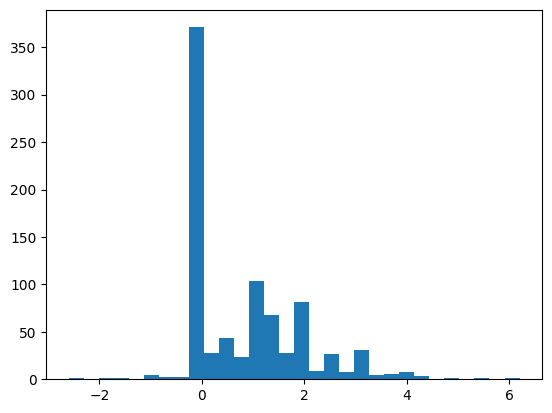

In [115]:
plt.hist(df['oldpeak'],bins=30)


In [116]:
oldpeak_median = df["oldpeak"].median()
df["oldpeak"] = df["oldpeak"].fillna(oldpeak_median)

In [117]:

chol_median = df["chol"].median()
df["chol"] = df["chol"].fillna(chol_median)

In [118]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,0
fbs,90
restecg,2
thalch,55


(array([  1.,   0.,   0.,   0.,  12., 149., 388., 218.,  73.,  20.]),
 array([  0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180., 200.]),
 <BarContainer object of 10 artists>)

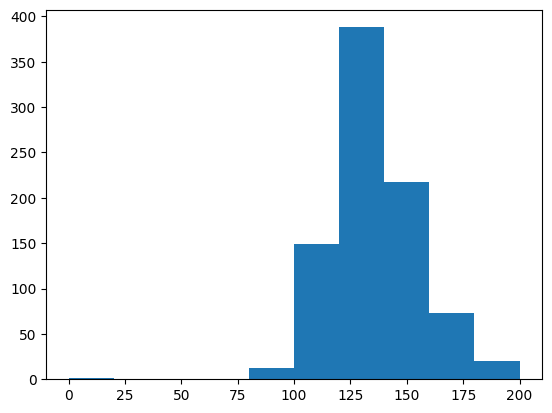

In [119]:
plt.hist(df["trestbps"])

In [120]:
trestbps_median = df["trestbps"].median()
df["trestbps"] = df["trestbps"].fillna(trestbps_median)

In [121]:
thalch_median = df["thalch"].median()
df["thalch"] = df["thalch"].fillna(thalch_median)

In [122]:
df['fbs']= df['fbs'].fillna(df['fbs'].mode()[0]).astype(str)
df['restecg']= df['restecg'].fillna(df['restecg'].mode()[0])
df['exang']= df['exang'].fillna(df['exang'].mode()[0]).astype(str)

/tmp/ipykernel_269/3699162626.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['fbs']= df['fbs'].fillna(df['fbs'].mode()[0]).astype(str)
/tmp/ipykernel_269/3699162626.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang']= df['exang'].fillna(df['exang'].mode()[0]).astype(str)


In [123]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [124]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df['fbs'] = le.fit_transform(df['fbs'])
df['exang'] = le.fit_transform(df['exang'])

# Columns to be one-hot encoded
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

# 1. Label Encoding for binary features
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['fbs'] = le.fit_transform(df['fbs'])
df['exang'] = le.fit_transform(df['exang'])

# 2. One-Hot Encoding for multi-categorical features without order
# We use drop_first=True to avoid the dummy variable trap

ohe = OneHotEncoder(sparse_output=False,drop='first')
df['cp'] = ohe.fit_transform(df[['cp']])
df['restecg'] = ohe.fit_transform(df[['restecg']])
df['slope'] = ohe.fit_transform(df[['slope']])
df['thal'] = ohe.fit_transform(df[['thal']])
df['dataset'] = ohe.fit_transform(df[['dataset']])


# Display the new structure
print(f"New shape: {df.shape}")
display(df.head())


New shape: (920, 15)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1,63,1,0.0,0.0,145.0,233.0,1,0.0,150.0,0,2.3,0.0,0.0,0
1,2,67,1,0.0,0.0,160.0,286.0,0,0.0,108.0,1,1.5,1.0,1.0,2
2,3,67,1,0.0,0.0,120.0,229.0,0,0.0,129.0,1,2.6,1.0,0.0,1
3,4,37,1,0.0,0.0,130.0,250.0,0,1.0,187.0,0,3.5,0.0,1.0,0
4,5,41,0,0.0,1.0,130.0,204.0,0,0.0,172.0,0,1.4,0.0,1.0,0


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features and target
# 'num' is our target (0 = no disease, 1-4 = degrees of disease)
X = df.drop(columns=['id', 'num'])
y = df['num']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Initialize and train the Decision Tree
Dtree_model = DecisionTreeClassifier(random_state=42)
Dtree_model.fit(X_train, y_train)



# Predictions of Random Forest model
y_pred = rf_model.predict(X_test)
# Predictions of Decision Tree model
y_pred_Dtree = Dtree_model.predict(X_test)

# Evaluation of Decision Tree Model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Evaluation of Decision Tree Model
print(f"Accuracy: {accuracy_score(y_test, y_pred_Dtree):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_Dtree))

Accuracy: 0.60

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.92      0.79        75
           1       0.55      0.50      0.52        54
           2       0.47      0.32      0.38        25
           3       0.41      0.27      0.33        26
           4       0.00      0.00      0.00         4

    accuracy                           0.60       184
   macro avg       0.43      0.40      0.40       184
weighted avg       0.57      0.60      0.57       184

Accuracy: 0.51

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.71        75
           1       0.45      0.44      0.45        54
           2       0.35      0.32      0.33        25
           3       0.22      0.23      0.23        26
           4       0.00      0.00      0.00         4

    accuracy                           0.51       184
   macro avg       0.34      0.35      0.34       184

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


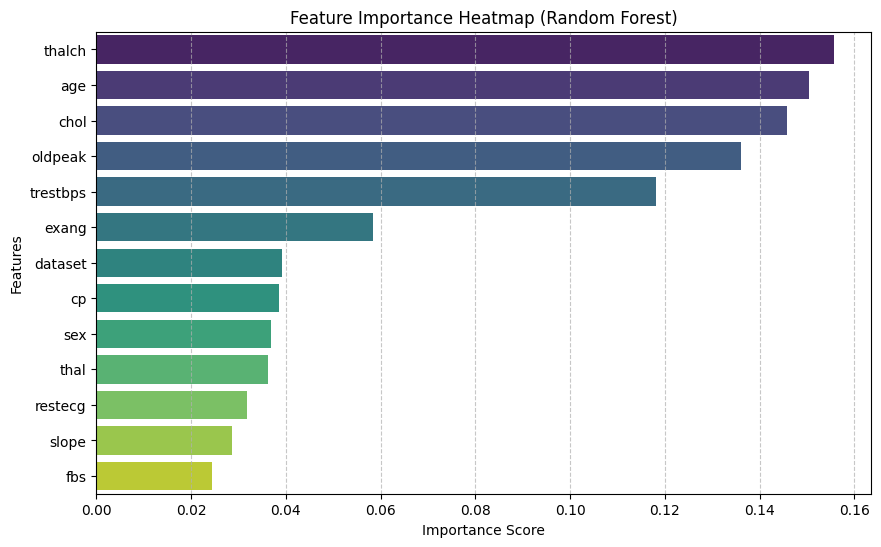

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting a 'Heatmap-style' Bar Plot for Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance Heatmap (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [133]:
# Save the feature importance plot for the README
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance Heatmap (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('feature_importance.png')
plt.close()

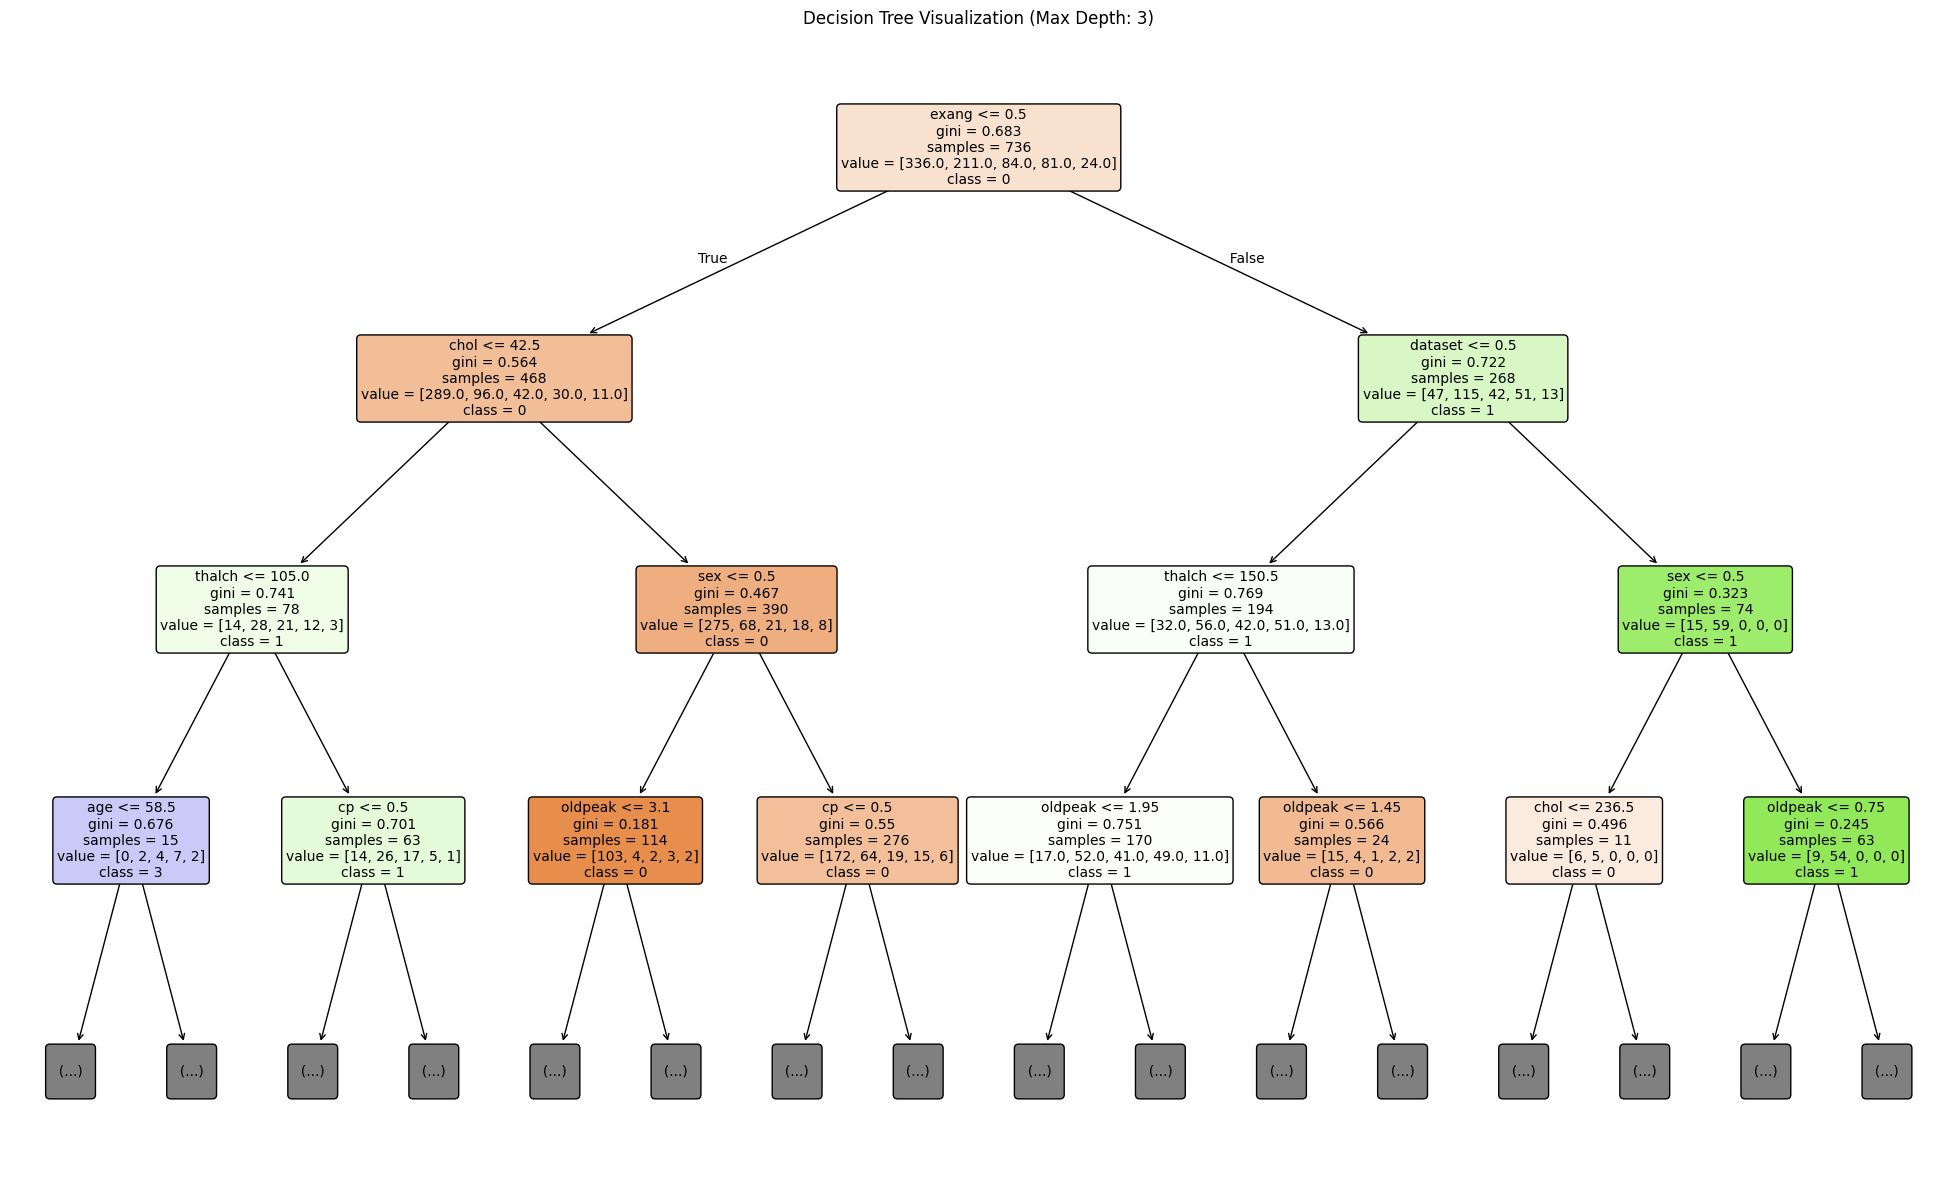

In [132]:
from sklearn.tree import plot_tree

# Set figure size for better readability
plt.figure(figsize=(25, 15))

# Plot the tree
# Note: max_depth is set to 3 for clarity, as the full tree might be too complex to view
plot_tree(Dtree_model,
          feature_names=X.columns.tolist(),
          class_names=[str(c) for c in np.unique(y)],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)

plt.title("Decision Tree Visualization (Max Depth: 3)")
plt.show()

In [134]:
# Save the decision tree plot for the README
plt.figure(figsize=(25, 15))
plot_tree(Dtree_model,
          feature_names=X.columns.tolist(),
          class_names=[str(c) for c in np.unique(y)],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)
plt.title("Decision Tree Visualization (Max Depth: 3)")
plt.savefig('decision_tree.png')
plt.close()

### Interpretation of the Decision Tree:
1. **Root Node**: The top node represents the most significant feature used to split the data.
2. **Color Intensity**: Darker colors indicate a higher purity in that node (i.e., most samples belong to a single class).
3. **Splitting Criteria**: Each internal node shows a logical test (e.g., `thalch <= 140.5`). If true, the flow goes to the left; if false, it goes to the right.
4. **Gini/Entropy**: This measures the impurity of the node. A Gini of 0.0 means all samples in that node belong to one class.
5. **Classes**: The classes (0-4) correspond to the presence and severity of heart disease.